# **Topik : Sistem Prediksi Risiko Penyakit Ginjal Kronis Menggunakan Perbandingan Algoritma Machine Learning Berbasis Web**
---
# **Pendahuluan**
---
Penyakit Ginjal Kronis (CKD) adalah masalah kesehatan global utama. Deteksi dini sangat penting untuk memperlambat perkembangan penyakit dan mencegah komplikasi serius seperti gagal ginjal. Proyek ini bertujuan membangun sistem prediksi risiko CKD dengan membandingkan beberapa algoritma machine learning (seperti Random Forest dan SVM) untuk menghasilkan klasifikasi yang akurat, dan menyajikannya dalam antarmuka berbasis web untuk edukasi dan kemudahan akses.
---
**Paparan, statistik dan sumber dari dataset yang digunakan**
---
Dataset yang digunakan adalah dataset Chronic Kidney Disease (CKD) dari UCI Machine Learning Repository (id 336). Dataset ini memiliki fitur medis terkait kondisi pasien, di antaranya:
* serum_creatinine: Tingkat kreatinin serum
* hemoglobin: Kadar hemoglobin
* albumin: Kadar albumin
* hypertension: Status hipertensi (yes/no)
* anemia: Status anemia (yes/no)
* blood_pressure: Tekanan darah
* age: Usia pasien
* classification: Label kelas (ckd = sakit ginjal kronis, notckd = tidak)

Terdapat total 24 fitur (numerik dan kategorikal) ditambah dengan 1 kolom target kelas. Dataset ini digunakan untuk memprediksi probabilitas seseorang menderita penyakit ginjal kronis berdasarkan metrik kesehatannya.



In [1]:
# Import library yang diperlukan
import pandas as pd  # Untuk manipulasi data
import numpy as np  # Untuk operasi numerik
import seaborn as sns  # Untuk visualisasi data
import matplotlib.pyplot as plt  # Untuk plotting grafik
import warnings
warnings.filterwarnings('ignore')

# Library untuk Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Library untuk model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



# **IMPORT DATA**
---


In [2]:
import os
file_path = 'data/raw/ckd.csv'
df = pd.read_csv(file_path)

# Membersihkan spasi pada nilai string di kolom target
df['classification'] = df['classification'].astype(str).str.strip()
df = df[df['classification'].isin(['ckd', 'notckd'])].copy()

df.head()


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# **DATA UNDERSTANDING**
---


In [3]:
print("data shape: ", df.shape)


data shape:  (400, 25)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               348 non-null

In [5]:
df.describe()


,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


# **DATA PREPARATION**
---


In [6]:
df.head()


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [7]:
df['classification'].value_counts()


classification
ckd       250
notckd    150
Name: count, dtype: int64

# **CLEANING DATA**
---
**MISSING VALUE**
---


In [8]:
df.isna().sum()


age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
classification               0
dtype: int64

**DATA UNIQUE**
---


In [9]:
df.nunique()


age                         76
blood_pressure              10
specific_gravity             5
albumin                      6
sugar                        6
red_blood_cells              2
pus_cell                     2
pus_cell_clumps              2
bacteria                     2
blood_glucose_random       146
blood_urea                 118
serum_creatinine            84
sodium                      34
potassium                   40
hemoglobin                 115
packed_cell_volume          42
white_blood_cell_count      89
red_blood_cell_count        45
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     2
pedal_edema                  2
anemia                       2
classification               2
dtype: int64

**DATA DUPLICATED**
---


In [10]:
df.duplicated().sum()


np.int64(0)

# **EXPLORATORY DATA ANALYSIS**
---


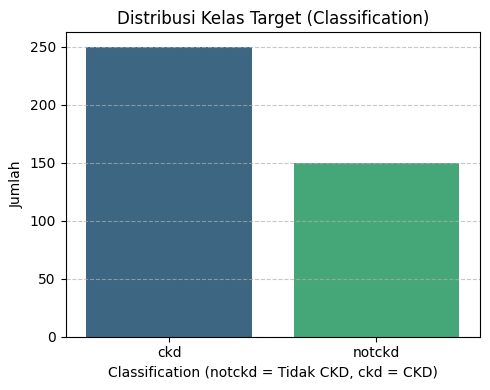

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='classification', palette='viridis')
plt.title("Distribusi Kelas Target (Classification)")
plt.xlabel("Classification (notckd = Tidak CKD, ckd = CKD)")
plt.ylabel("Jumlah")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**KORELASI ANTAR FITUR**
---


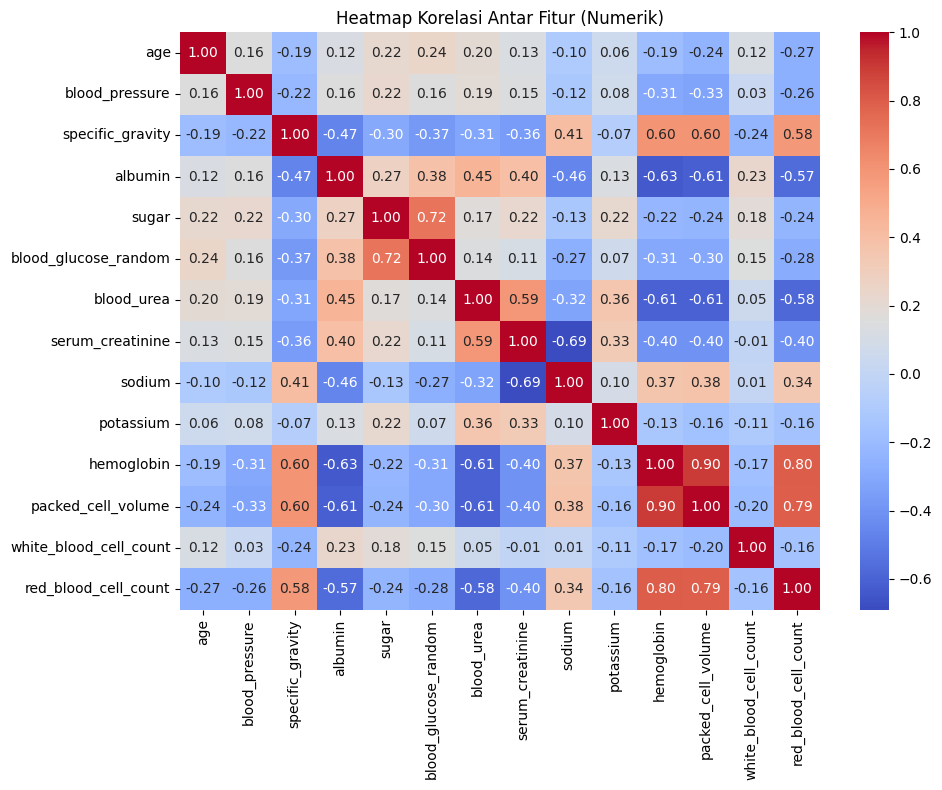

In [12]:
# Hanya menggunakan kolom numerik untuk korelasi
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur (Numerik)")
plt.tight_layout()
plt.show()


**OUTLIER**
---


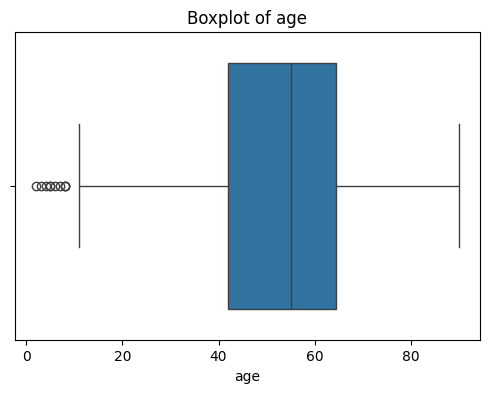

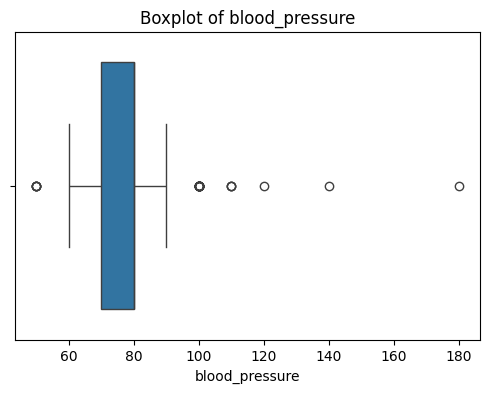

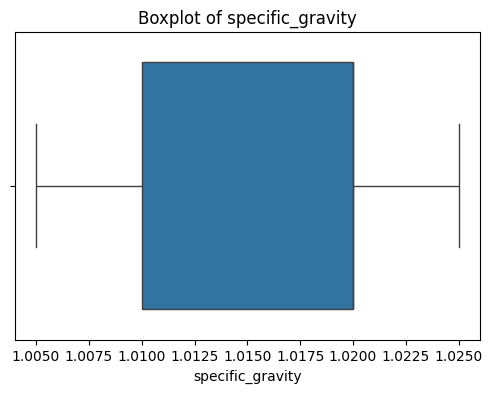

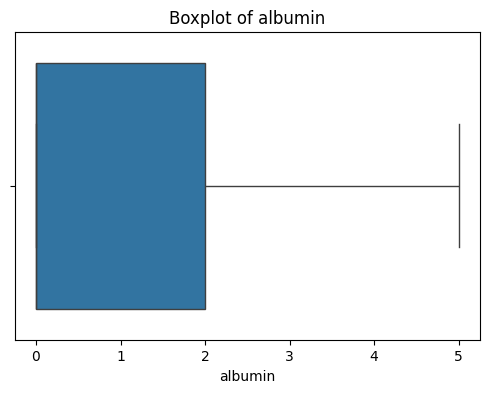

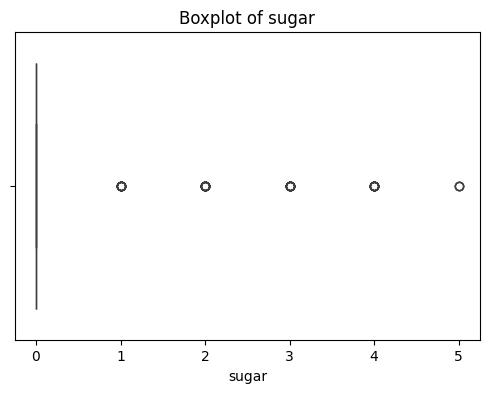

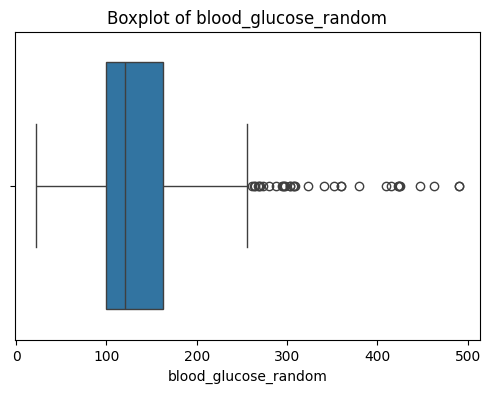

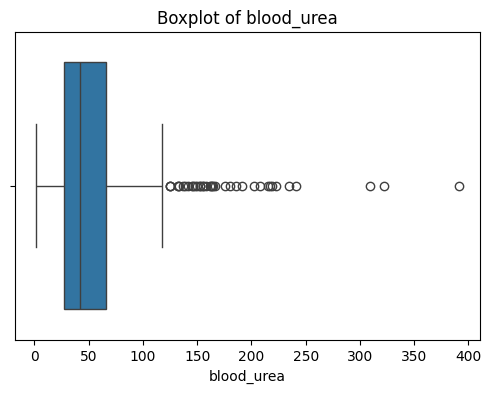

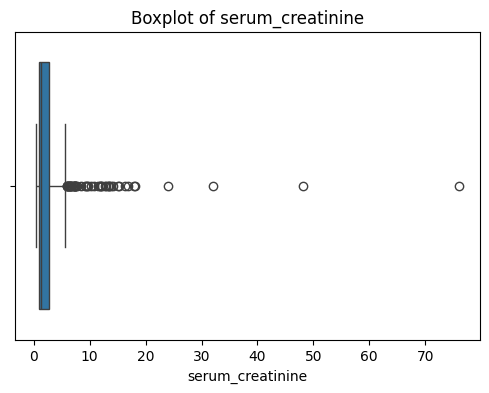

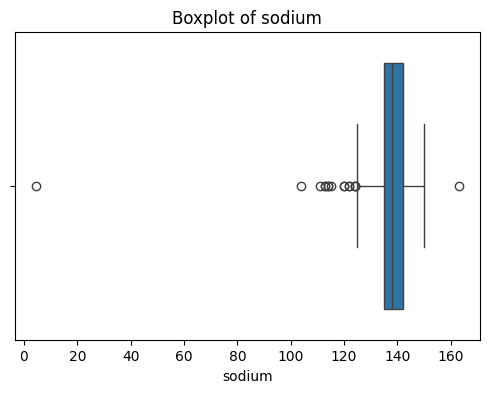

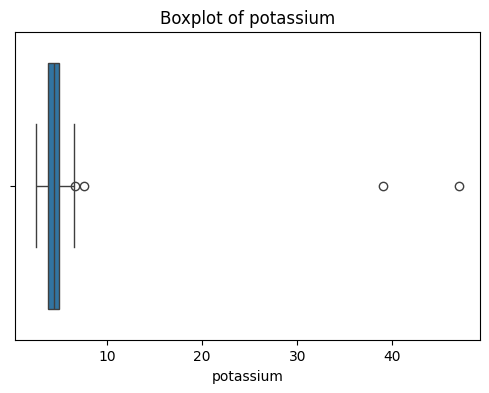

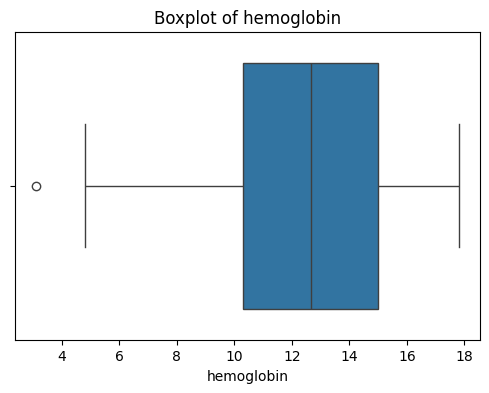

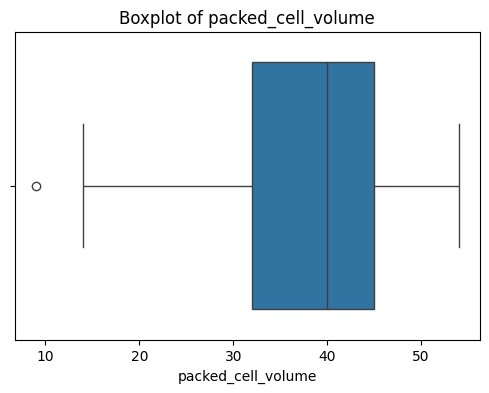

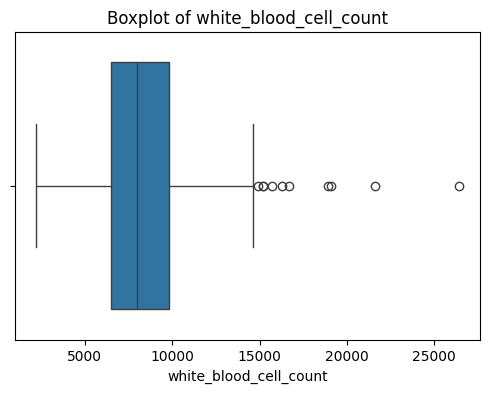

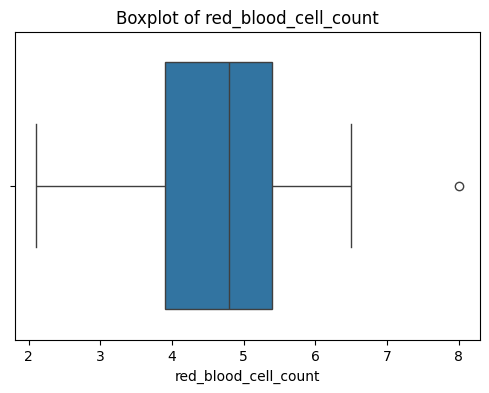

In [13]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


**DISTRIBUSI FITUR DATA**
---


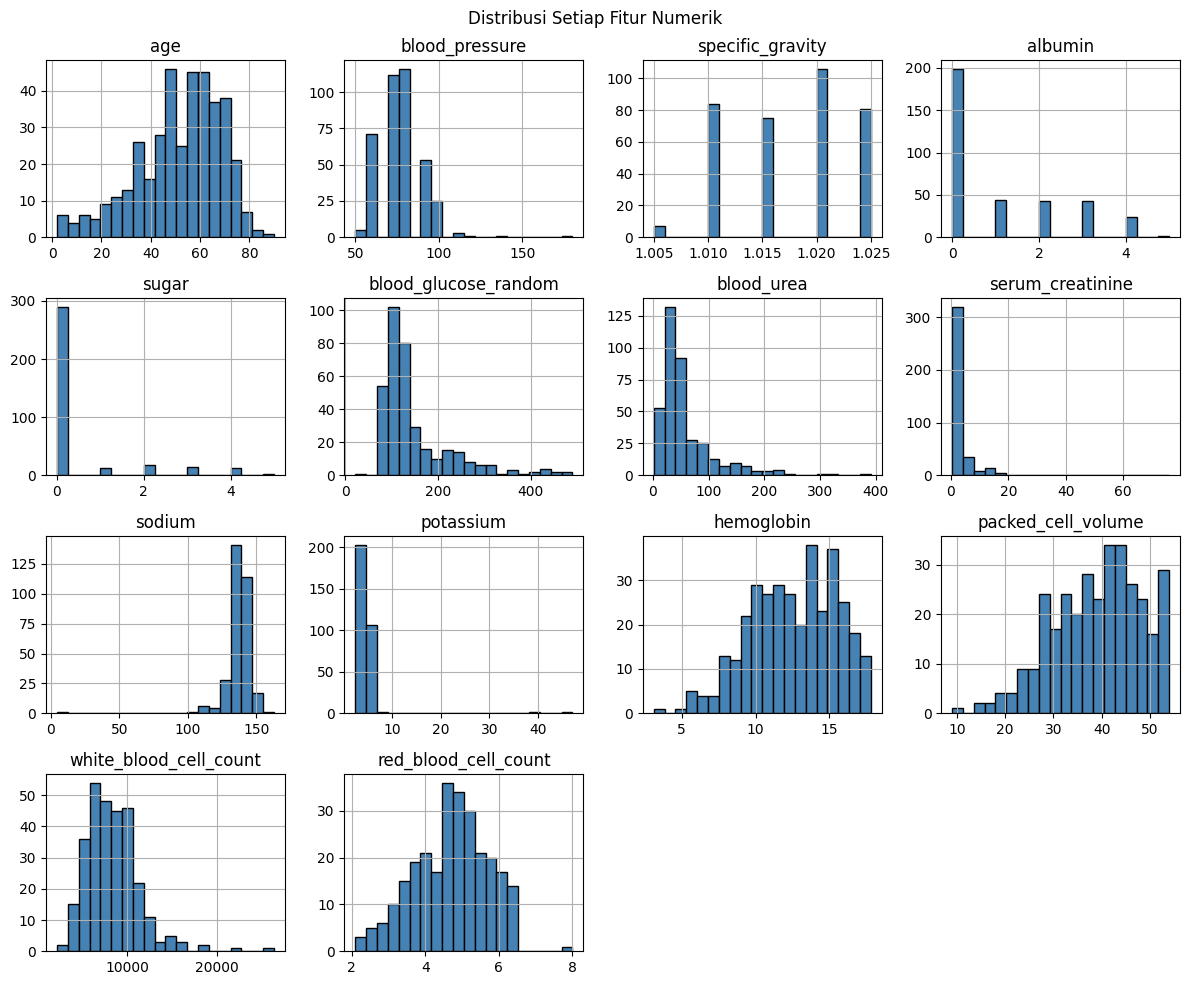

In [14]:
df[num_cols].hist(bins=20, figsize=(12,10), color='steelblue', edgecolor='black')
plt.suptitle("Distribusi Setiap Fitur Numerik")
plt.tight_layout()
plt.show()


**VISUALISASI FITUR & TARGET**
---


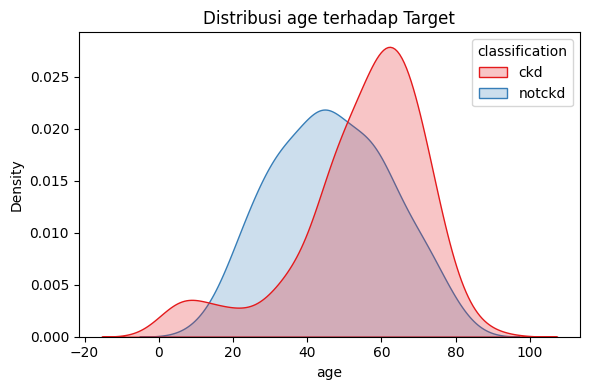

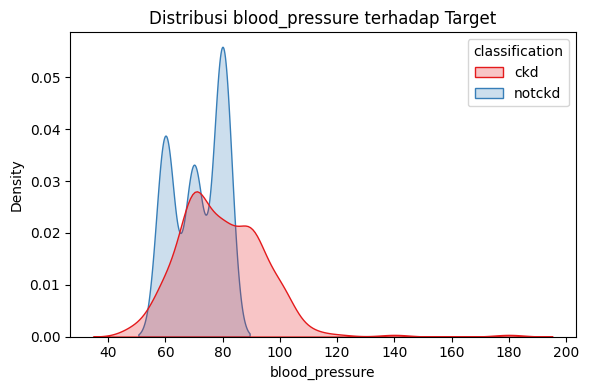

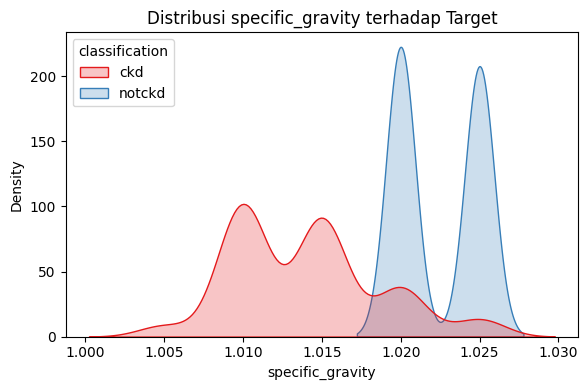

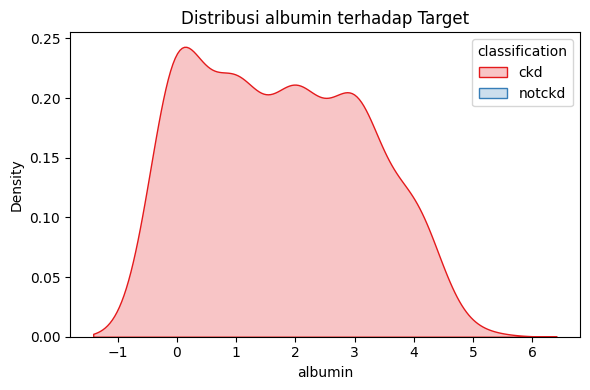

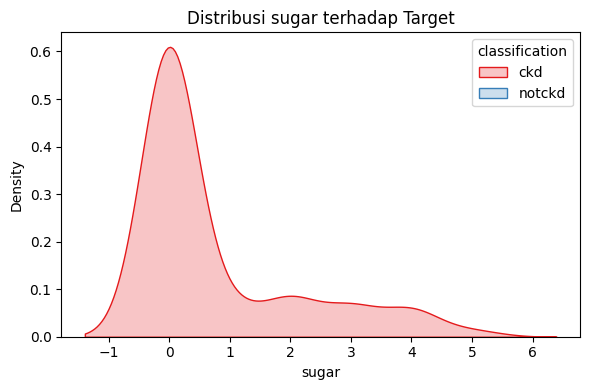

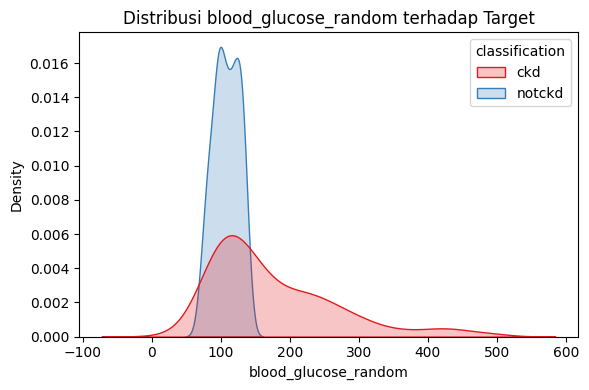

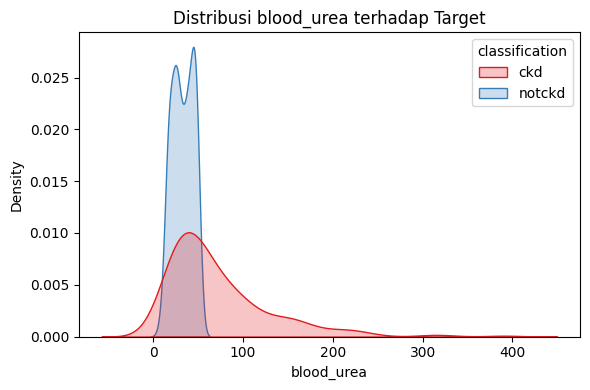

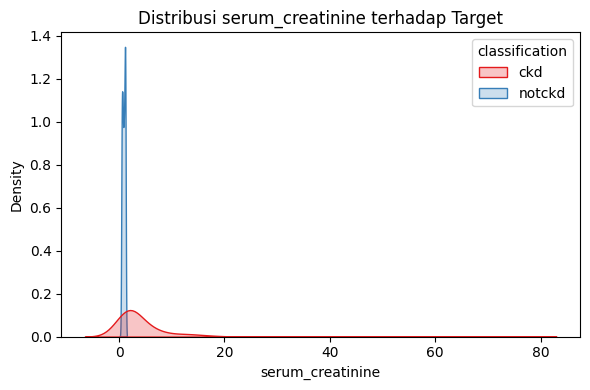

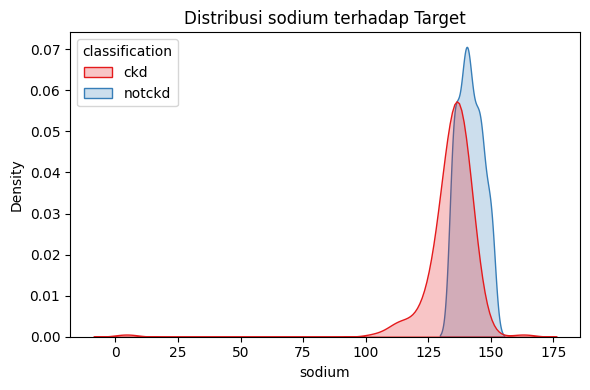

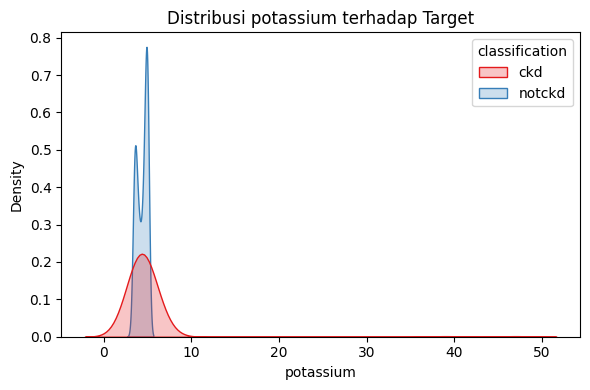

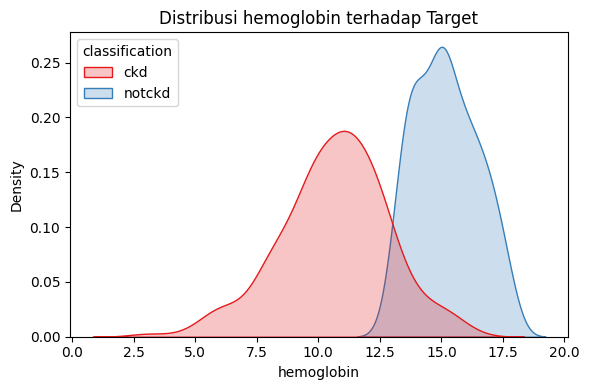

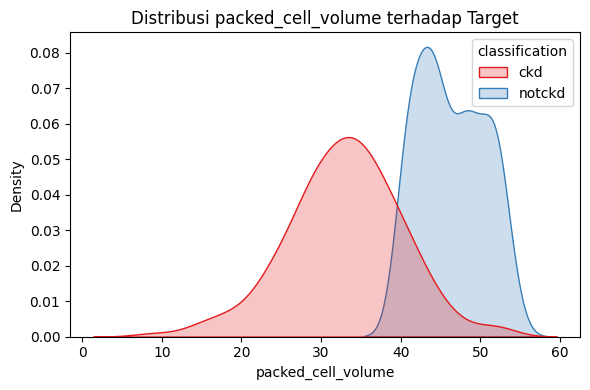

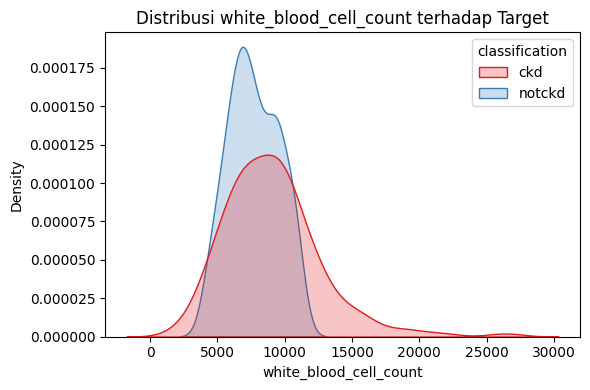

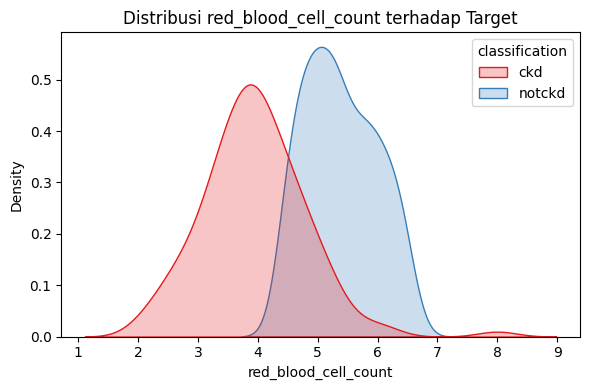

In [15]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue='classification', fill=True, common_norm=False, palette='Set1')
    plt.title(f"Distribusi {col} terhadap Target")
    plt.tight_layout()
    plt.show()


# **OUTCOME & PREPROCESSING**
---
**1. Imputasi, Normalisasi, & Encoding**
---


In [16]:
cat_cols = df.select_dtypes(exclude=np.number).columns.drop('classification').tolist()

# 1. Imputasi Nilai Kosong
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# 2. Scaling Numerik
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 3. Label Encoding untuk Kategorikal
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# 4. Encoding Target
df['classification'] = df['classification'].apply(lambda x: 1 if x == 'ckd' else 0)
df.head()


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
0,-0.210031,0.254214,0.421486,0.076249,-0.380269,1,1,0,0,-0.320122,...,0.603224,-0.197314,0.550044,1,1,0,0,0,0,1
1,-2.627234,-1.972476,0.421486,2.363728,-0.380269,1,1,0,0,-0.320122,...,-0.132789,-0.909782,0.074073,0,0,0,0,0,0,1
2,0.615355,0.254214,-1.421074,0.838742,2.507853,1,1,0,0,3.697618,...,-0.991470,-0.316059,0.074073,0,1,0,1,0,1,1
3,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,1,0,1,0,-0.373337,...,-0.868801,-0.632711,-0.996862,1,0,0,1,1,1,1
4,-0.033163,0.254214,-1.421074,0.838742,-0.380269,1,1,0,0,-0.519679,...,-0.500795,-0.395222,-0.163913,0,0,0,0,0,0,1


**2. Cek Distribusi Kelas Target (Setelah Encoding)**
---


In [17]:
df['classification'].value_counts()


classification
1    250
0    150
Name: count, dtype: int64

# **SPLITING DATA**
---
**FITUR & TARGET**
---


In [18]:
X = df.drop('classification', axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Ukuran Data Latih (X_train):", X_train.shape)
print("Ukuran Data Uji (X_test):", X_test.shape)


Ukuran Data Latih (X_train): (320, 24)
Ukuran Data Uji (X_test): (80, 24)


# **IMBALANCED DATASET**
**Mekanisme Imbalanced and Balanced Dataset**

Dalam dataset CKD ini, kelas `ckd` dan `notckd` memiliki perbedaan jumlah sehingga tidak seimbang (imbalanced). Hal ini dapat menyebabkan model condong pada kelas mayoritas. Oleh karena itu, kita menerapkan SMOTE (Synthetic Minority Over-sampling Technique) untuk menyeimbangkan data pada kelas latih.
---


Distribusi Sebelum SMOTE: Counter({1: 200, 0: 120})
Distribusi Setelah SMOTE: Counter({1: 200, 0: 200})


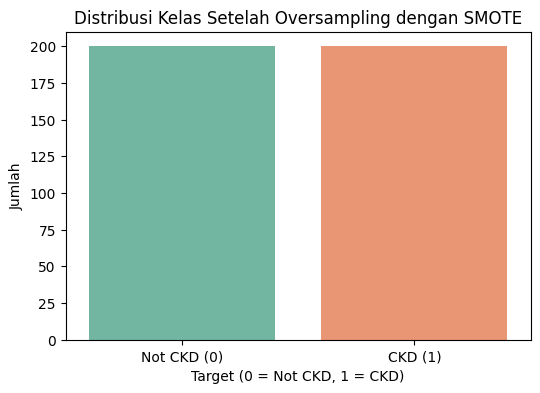

In [19]:
print("Distribusi Sebelum SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi Setelah SMOTE:", Counter(y_train_res))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res, palette='Set2')
plt.title('Distribusi Kelas Setelah Oversampling dengan SMOTE')
plt.xlabel('Target (0 = Not CKD, 1 = CKD)')
plt.ylabel('Jumlah')
plt.xticks(ticks=[0, 1], labels=['Not CKD (0)', 'CKD (1)'])
plt.show()


# **MODELLING**
---
**Random Forest (RF)**
---


In [20]:
# Inisialisasi model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("=== Laporan Klasifikasi Random Forest ===\n")
print(classification_report(y_test, y_pred_rf))
print('Akurasi Random Forest : {:.2f}%'.format(rf_acc * 100))


=== Laporan Klasifikasi Random Forest ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Akurasi Random Forest : 100.00%


**Support Vector Machine (SVM)**
---


In [21]:
# Inisialisasi model SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)
print("=== Laporan Klasifikasi SVM ===\n")
print(classification_report(y_test, y_pred_svm))
print('Akurasi SVM : {:.2f}%'.format(svm_acc * 100))


=== Laporan Klasifikasi SVM ===

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

Akurasi SVM : 98.75%


**Perbandingan Confusion Matrix**
---


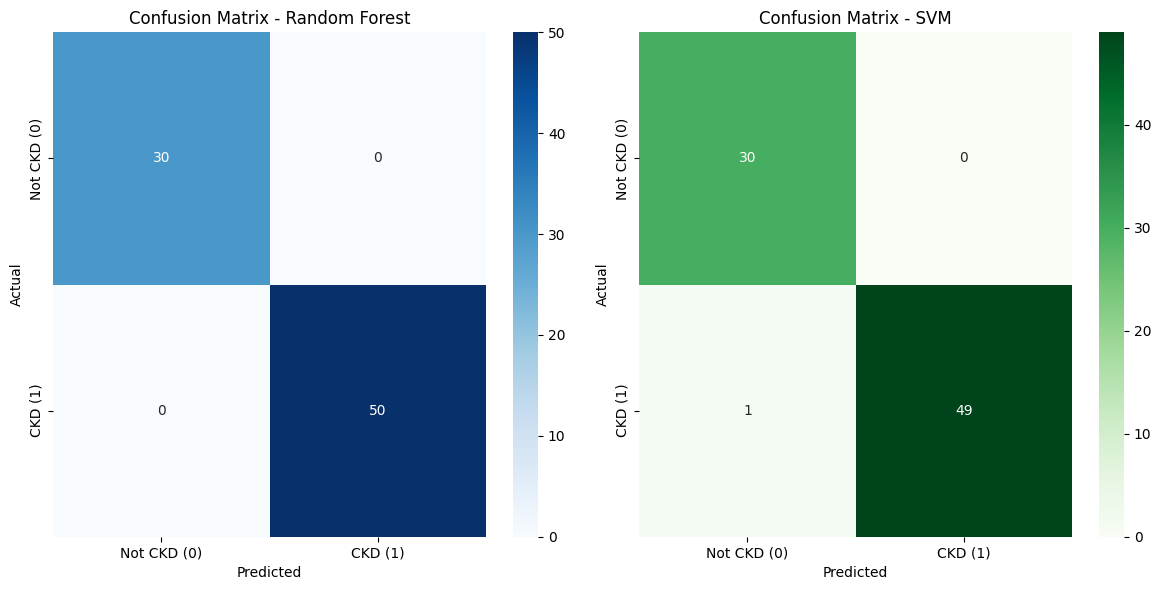

In [22]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Random Forest
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Not CKD (0)", "CKD (1)"], yticklabels=["Not CKD (0)", "CKD (1)"], ax=axes[0])
axes[0].set_title("Confusion Matrix - Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# SVM
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Greens", xticklabels=["Not CKD (0)", "CKD (1)"], yticklabels=["Not CKD (0)", "CKD (1)"], ax=axes[1])
axes[1].set_title("Confusion Matrix - SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
